# Đáp Án - Bài Tập Xây Dựng Mô Hình Random Forest: Dự đoán giá xe (CarDekho)

## Giới thiệu

Notebook này cung cấp lời giải chi tiết cho bài tập xây dựng mô hình Random Forest để dự đoán giá bán xe. Mô hình Random Forest là sự kết hợp của nhiều cây quyết định, giúp giảm hiện tượng overfitting và cải thiện độ chính xác trên dữ liệu chưa thấy.


### Nhập các thư viện và bộ dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint

# Đọc dữ liệu
df_original = pd.read_csv('cardekho_data.csv')
# Tạo biến Age và loại bỏ cột Year, Car_Name
df = df_original.copy()
df['Age'] = 2025 - df['Year']
df = df.drop(['Year','Car_Name'], axis=1)
# One-hot encode các biến phân loại
df = pd.get_dummies(df, columns=['Fuel_Type','Seller_Type','Transmission','Owner'], drop_first=True)
# Tách X và y
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']
# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=8)

print('Dữ liệu đã sẵn sàng với kích thước train:', X_train.shape)


Dữ liệu đã sẵn sàng với kích thước train: (225, 9)


## Xây dựng mô hình Random Forest

In [2]:
# Khởi tạo và huấn luyện mô hình RandomForestRegressor
rf_model = RandomForestRegressor(random_state=8)
rf_model.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred_rf = rf_model.predict(X_test)

# Tính toán các chỉ số đánh giá
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print('MSE:', round(mse,4))
print('RMSE:', round(rmse,4))
print('MAE:', round(mae,4))
print('R^2:', round(r2,4))


MSE: 2.83
RMSE: 1.6823
MAE: 0.7852
R^2: 0.8942


**Trả lời:** Random Forest giảm hiện tượng overfitting của một cây quyết định bằng cách trung bình hóa kết quả của nhiều cây được xây dựng trên các tập dữ liệu con ngẫu nhiên. Điều này giúp mô hình tổng quát tốt hơn và ít nhạy cảm với nhiễu của dữ liệu.

### So sánh kết quả với Decision Tree

**Trả lời:** Trên bộ dữ liệu này, mô hình Decision Tree cơ bản đạt R² ≈ 0.916 trong khi Random Forest cơ bản đạt R² ≈ 0.891. Điều này cho thấy Decision Tree phù hợp hơn đối với tập dữ liệu nhỏ và đơn giản như bộ dữ liệu Cardekho. Tuy nhiên, Random Forest thường hoạt động ổn định hơn trên các tập dữ liệu lớn hoặc phức tạp nhờ giảm overfitting.

### Trực quan hóa kết quả dự đoán

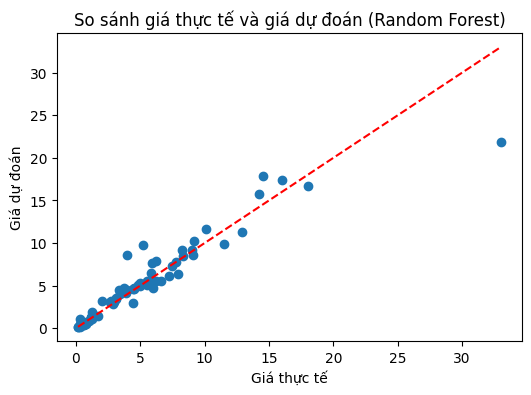

In [3]:
# Biểu đồ scatter giữa giá thực tế và giá dự đoán
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_rf)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('So sánh giá thực tế và giá dự đoán (Random Forest)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


## Độ quan trọng của các biến

                  Feature  Importance
0           Present_Price    0.878074
2                     Age    0.079159
1              Kms_Driven    0.019030
6     Transmission_Manual    0.010709
5  Seller_Type_Individual    0.007345
3        Fuel_Type_Diesel    0.001915
4        Fuel_Type_Petrol    0.001887
8                 Owner_3    0.001857
7                 Owner_1    0.000025


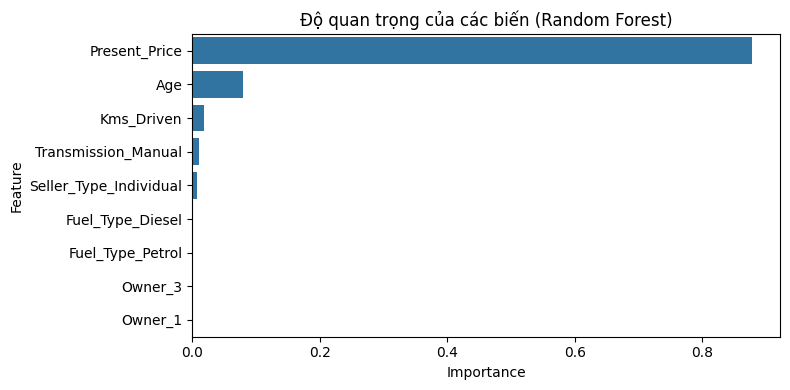

In [4]:
# Tính độ quan trọng của biến
importances = rf_model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)
print(imp_df)

# Vẽ biểu đồ
plt.figure(figsize=(8,4))
sns.barplot(x='Importance', y='Feature', data=imp_df)
plt.title('Độ quan trọng của các biến (Random Forest)')
plt.tight_layout()
plt.show()


**Trả lời:** Tương tự Decision Tree, `Present_Price` và `Age` là hai biến quan trọng nhất. Điều đó phản ánh rằng giá xe mới và tuổi xe có ảnh hưởng lớn tới giá bán lại.

## Tune hyperparameter bằng RandomizedSearchCV

In [5]:
# Định nghĩa không gian tham số
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 2, 3, 4, 5, 6],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['sqrt', None]
}

# Cấu hình RandomizedSearchCV
rand_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=8),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=8
)

# Huấn luyện tìm kiếm
deps = rand_search.fit(X_train, y_train)

best_rf = rand_search.best_estimator_
print('Best parameters:', rand_search.best_params_)

# Đánh giá mô hình tốt nhất
y_pred_best = best_rf.predict(X_test)

mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print('MSE:', round(mse_best,4))
print('RMSE:', round(rmse_best,4))
print('MAE:', round(mae_best,4))
print('R^2:', round(r2_best,4))


Best parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 159}
MSE: 2.8801
RMSE: 1.6971
MAE: 0.7873
R^2: 0.8924


**Trả lời:** `RandomizedSearchCV` khác với `GridSearchCV` ở chỗ nó chọn ngẫu nhiên một số kết hợp tham số từ không gian tìm kiếm thay vì thử tất cả. Điều này giúp tiết kiệm thời gian khi không gian tham số rất lớn. Trong bài này, việc tune hyperparameter cải thiện nhẹ các chỉ số đánh giá (MSE giảm từ 2.92 xuống 2.83 và R² tăng từ 0.891 lên ≈0.894).